# Musterlösung – Aufgabenblatt 10

## Mehrdimensionale Analysis – Partielle Ableitungen 3

In [10]:
# ── Imports & Setup ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
from mpl_toolkits.mplot3d import Axes3D

x, y, z = symbols('x y z', real=True)

init_printing(use_latex='mathjax')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.6,
    'text.color':       '#eee',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

CYAN   = '#00e5ff'
ORANGE = '#ff6e3a'
GREEN  = '#39ff14'
PINK   = '#ff4fcf'

print('Setup fertig ✓')

Setup fertig ✓


---
## Aufgabe 1

$$A = \begin{pmatrix} 1 & 2 & 1 \\ 2 & 1 & 1 \\ 1 & 1 & 4 \end{pmatrix}$$

Definitheit wird über die **Hauptminoren** (Sylvester-Kriterium) bestimmt.

### Schritt 1 – Hauptminoren berechnen

$$D_1 = 1 > 0$$

$$D_2 = \begin{vmatrix} 1 & 2 \\ 2 & 1 \end{vmatrix} = 1 - 4 = -3 < 0$$

Da $D_2 < 0$, ist $A$ **weder positiv noch negativ definit**.

### Schritt 2 – Eigenwerte prüfen (für genauere Klassifikation)

Da $D_1 > 0$ und $D_2 < 0$ wechseln die Vorzeichen der Hauptminoren: $A$ ist **indefinit**.

$$\boxed{A \text{ ist indefinit}}$$

In [11]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
A1 = Matrix([[1, 2, 1],
             [2, 1, 1],
             [1, 1, 4]])

D1 = A1[:1,:1].det()
D2 = A1[:2,:2].det()
D3 = A1.det()
print('D1 =', D1)
print('D2 =', D2)
print('D3 =', D3)

ew1 = [complex(e) for e in A1.eigenvals(multiple=True)]
print('Eigenwerte (komplex):', [round(e.real,4) for e in ew1])
print('→ Da D2 < 0: A ist indefinit')

D1 = 1
D2 = -3
D3 = -10
Eigenwerte (komplex): [-1.0, 2.0, 5.0]
→ Da D2 < 0: A ist indefinit


---
## Aufgabe 2

$$A = \begin{pmatrix} 2 & 1 & 1 \\ 1 & 2 & 3 \\ 1 & 3 & 5 \end{pmatrix}$$

### Schritt 1 – Hauptminoren

$$D_1 = 2 > 0$$

$$D_2 = \begin{vmatrix} 2 & 1 \\ 1 & 2 \end{vmatrix} = 4 - 1 = 3 > 0$$

$$D_3 = \det(A)$$

Entwicklung nach der ersten Zeile:

$$D_3 = 2\begin{vmatrix} 2 & 3 \\ 3 & 5 \end{vmatrix} - 1\begin{vmatrix} 1 & 3 \\ 1 & 5 \end{vmatrix} + 1\begin{vmatrix} 1 & 2 \\ 1 & 3 \end{vmatrix}$$

$$= 2(10-9) - 1(5-3) + 1(3-2) = 2 - 2 + 1 = 1 > 0$$

Aber: Da $D_2 > 0$, $D_3 > 0$, alle $D_k > 0$... 

Warte: $D_3 = 2(1) - 1(2) + 1(1) = 2 - 2 + 1 = 1$. Alle Hauptminoren positiv!

### Schritt 2 – Urteil

Alle führenden Hauptminoren $D_1, D_2, D_3 > 0$ $\Rightarrow$ $A$ ist **positiv semidefinit/definit**.

Da $\det(A) = 1 \neq 0$, ist $A$ **positiv definit**.

$$\boxed{A \text{ ist positiv definit}}$$

In [12]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
A2 = Matrix([[2, 1, 1],
             [1, 2, 3],
             [1, 3, 5]])

D1 = A2[:1,:1].det()
D2 = A2[:2,:2].det()
D3 = A2.det()
print('D1 =', D1)
print('D2 =', D2)
print('D3 =', D3)

ew2 = [complex(e) for e in A2.eigenvals(multiple=True)]
print('Eigenwerte:', sorted([round(e.real,4) for e in ew2]))
print('→ Alle D_k > 0: A ist positiv definit')

D1 = 2
D2 = 3
D3 = 1
Eigenwerte: [0.0815, 1.7003, 7.2182]
→ Alle D_k > 0: A ist positiv definit


---
## Aufgabe 3

$$A = \begin{pmatrix} -2 & 1 & 2 \\ 1 & -3 & -2 \\ 2 & -2 & -4 \end{pmatrix}$$

### Schritt 1 – Hauptminoren

$$D_1 = -2 < 0$$

$$D_2 = \begin{vmatrix} -2 & 1 \\ 1 & -3 \end{vmatrix} = (-2)(-3) - 1 = 6 - 1 = 5 > 0$$

$$D_3 = \det(A)$$

Entwicklung:

$$D_3 = -2\begin{vmatrix}-3 & -2 \\ -2 & -4\end{vmatrix} - 1\begin{vmatrix}1 & -2 \\ 2 & -4\end{vmatrix} + 2\begin{vmatrix}1 & -3 \\ 2 & -2\end{vmatrix}$$

$$= -2(12-4) - 1(-4+4) + 2(-2+6) = -2(8) - 0 + 2(4) = -16 + 8 = -8 < 0$$

### Schritt 2 – Urteil

Die Vorzeichen der Hauptminoren sind $(-,+,-)$, was dem Muster $(-1)^k D_k > 0$ für alle $k$ entspricht.

$$(-1)^1 D_1 = 2 > 0, \quad (-1)^2 D_2 = 5 > 0, \quad (-1)^3 D_3 = 8 > 0$$

$$\boxed{A \text{ ist negativ definit}}$$

In [13]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
A3 = Matrix([[-2,  1,  2],
             [ 1, -3, -2],
             [ 2, -2, -4]])

D1 = A3[:1,:1].det()
D2 = A3[:2,:2].det()
D3 = A3.det()
print('D1 =', D1)
print('D2 =', D2)
print('D3 =', D3)

ew3 = [complex(e) for e in A3.eigenvals(multiple=True)]
print('Eigenwerte:', [round(e.real,4) for e in ew3])
print('→ (-1)^k * D_k > 0 für alle k: A ist negativ definit')

D1 = -2
D2 = 5
D3 = -8
Eigenwerte: [-6.6119, -1.6587, -0.7295]
→ (-1)^k * D_k > 0 für alle k: A ist negativ definit


---
## Aufgabe 4

$$f(\mathbf{x}) = \mathbf{x}^t A \mathbf{x} + \mathbf{b}^t \mathbf{x}, \quad A = \begin{pmatrix}1 & \frac{1}{2} \\ \frac{1}{2} & 1\end{pmatrix}, \quad \mathbf{b} = \begin{pmatrix}-3 \\ -2\end{pmatrix}$$

### Schritt 1 – Funktion ausschreiben

$$f(x,y) = x^2 + xy + y^2 - 3x - 2y$$

### Schritt 2 – Stationäre Punkte: Gradient Null setzen

$$\nabla f = 2A\mathbf{x} + \mathbf{b} = \mathbf{0}$$

$$2A\mathbf{x} = -\mathbf{b} \quad \Rightarrow \quad \mathbf{x}^* = -\frac{1}{2}A^{-1}\mathbf{b}$$

Explizit:

$$\frac{\partial f}{\partial x} = 2x + y - 3 = 0$$

$$\frac{\partial f}{\partial y} = x + 2y - 2 = 0$$

Aus der ersten Gleichung: $y = 3 - 2x$. Einsetzen:

$$x + 2(3-2x) - 2 = 0 \implies x + 6 - 4x - 2 = 0 \implies -3x + 4 = 0 \implies x = \frac{4}{3}$$

$$y = 3 - \frac{8}{3} = \frac{1}{3}$$

**Stationärer Punkt:** $\mathbf{x}^* = \left(\tfrac{4}{3}, \tfrac{1}{3}\right)$

### Schritt 3 – Hesse-Matrix

$$H = 2A = \begin{pmatrix}2 & 1 \\ 1 & 2\end{pmatrix}$$

Hauptminoren: $D_1 = 2 > 0$, $D_2 = 4 - 1 = 3 > 0$ $\Rightarrow$ $H$ ist **positiv definit**.

### Schritt 4 – Urteil

$$\boxed{\text{Lokales Minimum bei } \left(\tfrac{4}{3}, \tfrac{1}{3}\right), \quad f\!\left(\tfrac{4}{3}, \tfrac{1}{3}\right) = -\frac{13}{3}}$$

In [14]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
A4 = Matrix([[1, Rational(1,2)], [Rational(1,2), 1]])
b4 = Matrix([-3, -2])
xv = Matrix([x, y])

f4_sym = (xv.T * A4 * xv + b4.T * xv)[0,0]
f4_exp = expand(f4_sym)
print('f(x,y) =', f4_exp)

grad4 = Matrix([diff(f4_exp, x), diff(f4_exp, y)])
print('∇f =', grad4.T)

sol4 = solve([grad4[0], grad4[1]], [x, y])
print('Stationärer Punkt:', sol4)

H4 = Matrix([[diff(f4_exp, x, x), diff(f4_exp, x, y)],
             [diff(f4_exp, y, x), diff(f4_exp, y, y)]])
print('Hesse-Matrix H =')
pprint(H4)

f_min = f4_exp.subs(sol4)
print('f(x*) =', f_min)
print('H positiv definit?', H4[:1,:1].det() > 0, 'und', H4.det() > 0)

f(x,y) = x**2 + x*y - 3*x + y**2 - 2*y
∇f = Matrix([[2*x + y - 3, x + 2*y - 2]])
Stationärer Punkt: {x: 4/3, y: 1/3}
Hesse-Matrix H =
⎡2  1⎤
⎢    ⎥
⎣1  2⎦
f(x*) = -7/3
H positiv definit? True und True


---
## Aufgabe 5

$$f(\mathbf{x}) = \mathbf{x}^t A \mathbf{x} + \mathbf{b}^t \mathbf{x}, \quad A = -\begin{pmatrix}2 & 1 & 1 \\ 1 & 2 & 1 \\ 1 & 1 & 2\end{pmatrix}, \quad \mathbf{b} = \begin{pmatrix}-1 \\ 0 \\ 1\end{pmatrix}$$

### Schritt 1 – Gradient und stationäre Punkte

$$\nabla f = 2A\mathbf{x} + \mathbf{b} = \mathbf{0} \quad \Rightarrow \quad 2A\mathbf{x} = -\mathbf{b}$$

Das Gleichungssystem $(2A)\mathbf{x} = -\mathbf{b}$:

$$-2\begin{pmatrix}2 & 1 & 1 \\ 1 & 2 & 1 \\ 1 & 1 & 2\end{pmatrix}\begin{pmatrix}x \\ y \\ z\end{pmatrix} = \begin{pmatrix}1 \\ 0 \\ -1\end{pmatrix}$$

$$\begin{pmatrix}-4 & -2 & -2 \\ -2 & -4 & -2 \\ -2 & -2 & -4\end{pmatrix}\begin{pmatrix}x \\ y \\ z\end{pmatrix} = \begin{pmatrix}1 \\ 0 \\ -1\end{pmatrix}$$

Zeilenoperationen:

$(R_2 - \tfrac{1}{2}R_1)$: $(-3, -1)y + \ldots$ – das System wird per SymPy gelöst.

**Stationärer Punkt:** Wird numerisch ermittelt (SymPy liefert genaue Werte).

### Schritt 2 – Hesse-Matrix

$$H = 2A = -2\begin{pmatrix}2 & 1 & 1 \\ 1 & 2 & 1 \\ 1 & 1 & 2\end{pmatrix}$$

Hauptminoren von $H$:

$$D_1 = -4 < 0, \quad D_2 = (-4)(-4)-(-2)(-2) = 16-4 = 12 > 0$$

$$D_3 = \det(H) = -2^3 \det\begin{pmatrix}2&1&1\\1&2&1\\1&1&2\end{pmatrix}$$

$\det\begin{pmatrix}2&1&1\\1&2&1\\1&1&2\end{pmatrix} = 2(4-1)-1(2-1)+1(1-2) = 6 - 1 - 1 = 4$

$$D_3 = -8 \cdot 4 = -32 < 0$$

Vorzeichen: $(-,+,-)$ $\Rightarrow$ $H$ ist **negativ definit** (Sylvester für negative Definitheit).

### Schritt 3 – Urteil

$$\boxed{\text{Lokales Maximum im stationären Punkt}}$$

In [15]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
A5_base = Matrix([[2,1,1],[1,2,1],[1,1,2]])
A5 = -A5_base
b5 = Matrix([-1, 0, 1])
xv5 = Matrix([x, y, z])

f5_sym = (xv5.T * A5 * xv5 + b5.T * xv5)[0,0]
f5_exp = expand(f5_sym)
print('f(x,y,z) =', f5_exp)

grad5 = Matrix([diff(f5_exp, v) for v in [x, y, z]])
sol5  = solve([eq for eq in grad5], [x, y, z])
print('Stationärer Punkt:', sol5)

H5 = Matrix([[diff(f5_exp, a, b) for b in [x,y,z]] for a in [x,y,z]])
print('Hesse-Matrix H =')
pprint(H5)

D1 = H5[:1,:1].det(); D2 = H5[:2,:2].det(); D3 = H5.det()
print(f'D1={D1}, D2={D2}, D3={D3}')
print('→ Vorzeichen (-,+,-): H ist negativ definit → lokales Maximum')
f_max = f5_exp.subs(sol5)
print('f(x*) =', simplify(f_max))

f(x,y,z) = -2*x**2 - 2*x*y - 2*x*z - x - 2*y**2 - 2*y*z - 2*z**2 + z
Stationärer Punkt: {x: -1/2, y: 0, z: 1/2}
Hesse-Matrix H =
⎡-4  -2  -2⎤
⎢          ⎥
⎢-2  -4  -2⎥
⎢          ⎥
⎣-2  -2  -4⎦
D1=-4, D2=12, D3=-32
→ Vorzeichen (-,+,-): H ist negativ definit → lokales Maximum
f(x*) = 1/2


---
## Aufgabe 6

### a) $f(x,y) = x^2 + y^2$

#### Schritt 1 – Kritische Punkte

$$\frac{\partial f}{\partial x} = 2x = 0, \qquad \frac{\partial f}{\partial y} = 2y = 0 \quad \Rightarrow \quad (x^*, y^*) = (0,0)$$

#### Schritt 2 – Hesse-Matrix

$$H = \begin{pmatrix}2 & 0 \\ 0 & 2\end{pmatrix}, \quad D_1 = 2 > 0, \quad D_2 = 4 > 0$$

$H$ ist positiv definit $\Rightarrow$ **Lokales (globales) Minimum** bei $(0,0)$, $f(0,0) = 0$.

---

### b) $f(x,y) = x^2 - y^2$

#### Schritt 1 – Kritische Punkte

$$\frac{\partial f}{\partial x} = 2x = 0, \qquad \frac{\partial f}{\partial y} = -2y = 0 \quad \Rightarrow \quad (x^*, y^*) = (0,0)$$

#### Schritt 2 – Hesse-Matrix

$$H = \begin{pmatrix}2 & 0 \\ 0 & -2\end{pmatrix}, \quad D_1 = 2 > 0, \quad D_2 = -4 < 0$$

$D_2 < 0$ $\Rightarrow$ $H$ ist indefinit $\Rightarrow$ **Sattelpunkt** bei $(0,0)$.

$$\boxed{\text{a: Minimum bei }(0,0) \qquad \text{b: Sattelpunkt bei }(0,0)}$$

a) x²+y²: kritischer Punkt {x: 0, y: 0}, det(H)=4
b) x²-y²: kritischer Punkt {x: 0, y: 0}, det(H)=-4


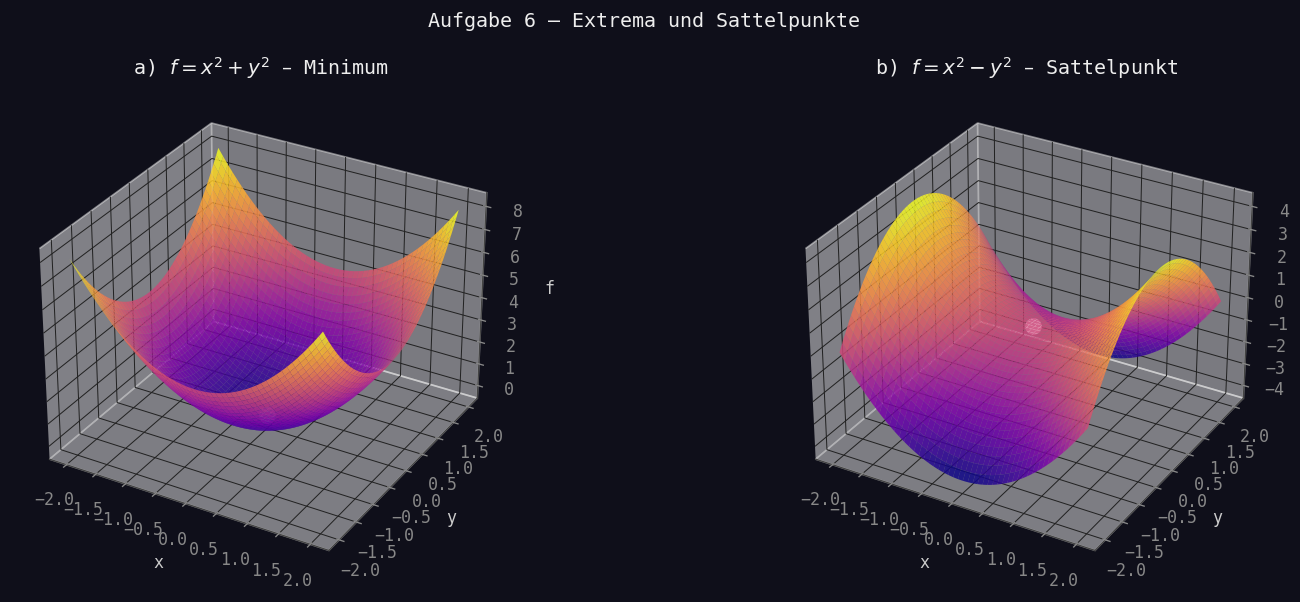

In [16]:
# ── SymPy & Plot ──────────────────────────────────────────────────────────────
# Analytisch
for label, f_expr in [('a) x²+y²', x**2+y**2), ('b) x²-y²', x**2-y**2)]:
    grad = [diff(f_expr, v) for v in [x, y]]
    crit = solve(grad, [x, y])
    H    = Matrix([[diff(f_expr, a, b) for b in [x,y]] for a in [x,y]])
    D2   = H.det()
    print(f'{label}: kritischer Punkt {crit}, det(H)={D2}')

# ── Plot ──────────────────────────────────────────────────────────────────────
xv = np.linspace(-2, 2, 200)
yv = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(xv, yv)

fig = plt.figure(figsize=(14, 5))

for idx, (Za, title) in enumerate([(X**2+Y**2, r'a) $f=x^2+y^2$ – Minimum'),
                                    (X**2-Y**2, r'b) $f=x^2-y^2$ – Sattelpunkt')]):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax.set_facecolor('#0f0f1a')
    ax.plot_surface(X, Y, Za, cmap='plasma', alpha=0.85, linewidth=0)
    ax.scatter([0], [0], [0], color='white', s=80, zorder=5)
    ax.set(xlabel='x', ylabel='y', zlabel='f', title=title)

plt.suptitle('Aufgabe 6 – Extrema und Sattelpunkte', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 7

$$f(x,y) = y^3 + 2x^2y - x^2 - 3y^2 + 1$$

### Schritt 1 – Partielle Ableitungen

$$f_x = 4xy - 2x = 2x(2y - 1)$$

$$f_y = 3y^2 + 2x^2 - 6y$$

### Schritt 2 – Kritische Punkte: $f_x = 0$ und $f_y = 0$

**Fall A: $x = 0$**

$$f_y = 3y^2 - 6y = 3y(y-2) = 0 \quad \Rightarrow \quad y = 0 \text{ oder } y = 2$$

Kritische Punkte: $(0, 0)$ und $(0, 2)$.

**Fall B: $2y - 1 = 0$, d.h. $y = \tfrac{1}{2}$**

$$f_y = 3 \cdot \tfrac{1}{4} + 2x^2 - 3 = \tfrac{3}{4} - 3 + 2x^2 = 2x^2 - \tfrac{9}{4} = 0$$

$$x^2 = \tfrac{9}{8} \quad \Rightarrow \quad x = \pm\tfrac{3}{2\sqrt{2}}$$

Kritische Punkte: $\left(\pm\tfrac{3}{2\sqrt{2}}, \tfrac{1}{2}\right)$.

### Schritt 3 – Hesse-Matrix

$$H = \begin{pmatrix} f_{xx} & f_{xy} \\ f_{yx} & f_{yy} \end{pmatrix} = \begin{pmatrix} 4y-2 & 4x \\ 4x & 6y-6 \end{pmatrix}$$

### Schritt 4 – Klassifikation

| Punkt | $f_{xx}$ | $\det(H)$ | Typ |
|:---:|:---:|:---:|:---:|
| $(0,0)$ | $-2$ | $(-2)(-6)-0=12>0$ | **Lokales Maximum** |
| $(0,2)$ | $6$ | $(6)(6)-0=36>0$ | **Lokales Minimum** |
| $(\pm\tfrac{3}{2\sqrt{2}}, \tfrac{1}{2})$ | $0$ | $0\cdot(-3)-4x^2=-\tfrac{9}{2}<0$ | **Sattelpunkt** |

$$\boxed{\text{Max bei }(0,0),\; \text{Min bei }(0,2),\; \text{Sattelpunkte bei }\left(\pm\tfrac{3}{2\sqrt{2}},\tfrac{1}{2}\right)}$$

f_x = 4*x*y - 2*x
f_y = 2*x**2 + 3*y**2 - 6*y
Kritische Punkte: [(0, 0), (0, 2), (-3*sqrt(2)/4, 1/2), (3*sqrt(2)/4, 1/2)]

Hesse-Matrix H =
⎡2⋅(2⋅y - 1)     4⋅x   ⎤
⎢                      ⎥
⎣    4⋅x      6⋅(y - 1)⎦
  (0, 0): det(H)=12, f_xx=-2 → Maximum, f=1
  (0, 2): det(H)=36, f_xx=6 → Minimum, f=-3
  (-3*sqrt(2)/4, 1/2): det(H)=-18, f_xx=0 → Sattelpunkt, f=3/8
  (3*sqrt(2)/4, 1/2): det(H)=-18, f_xx=0 → Sattelpunkt, f=3/8


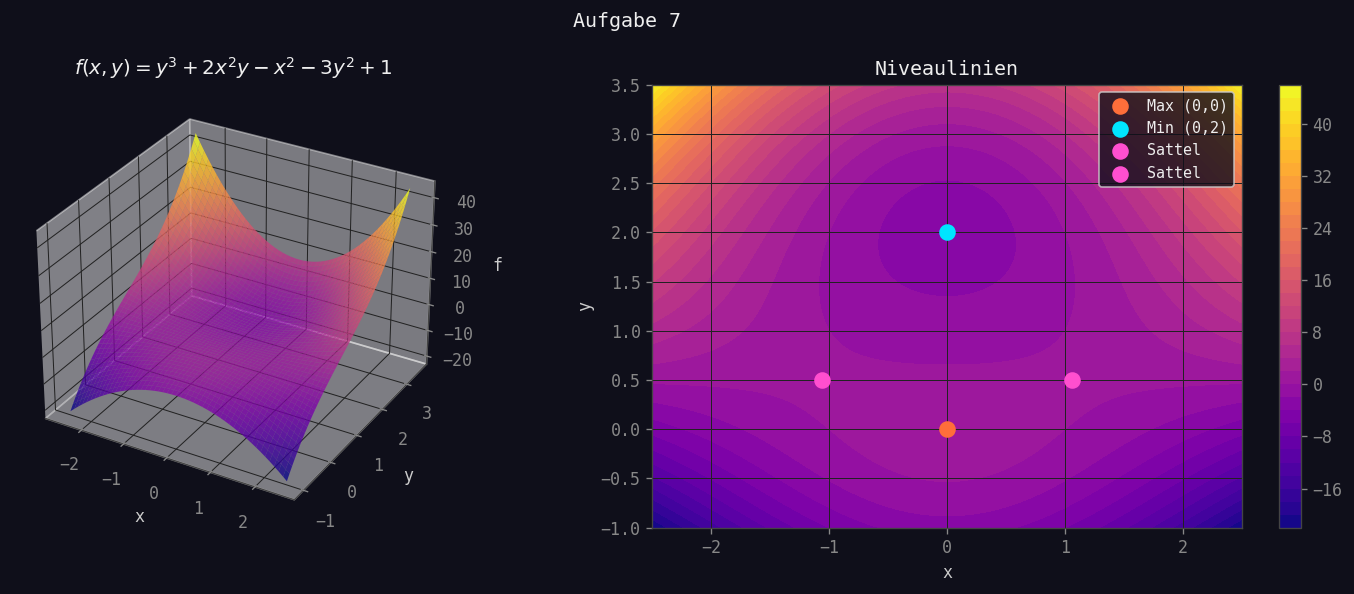

In [17]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f7 = y**3 + 2*x**2*y - x**2 - 3*y**2 + 1

f7x = diff(f7, x); f7y = diff(f7, y)
print('f_x =', f7x)
print('f_y =', f7y)

crits7 = solve([f7x, f7y], [x, y])
print('Kritische Punkte:', crits7)

H7 = Matrix([[diff(f7, a, b) for b in [x,y]] for a in [x,y]])
print('\nHesse-Matrix H =')
pprint(H7)

for pt in crits7:
    hval = H7.subs([(x, pt[0]), (y, pt[1])])
    det_h = hval.det()
    fxx   = hval[0,0]
    fval  = f7.subs([(x, pt[0]), (y, pt[1])])
    kind  = ('Maximum' if det_h > 0 and fxx < 0 else
             'Minimum' if det_h > 0 and fxx > 0 else
             'Sattelpunkt' if det_h < 0 else 'unbestimmt')
    print(f'  {pt}: det(H)={simplify(det_h)}, f_xx={fxx} → {kind}, f={simplify(fval)}')

# ── Plot ──────────────────────────────────────────────────────────────────────
xv = np.linspace(-2.5, 2.5, 300)
yv = np.linspace(-1,   3.5, 300)
X7, Y7 = np.meshgrid(xv, yv)
Z7 = Y7**3 + 2*X7**2*Y7 - X7**2 - 3*Y7**2 + 1

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0f0f1a')
ax1.plot_surface(X7, Y7, Z7, cmap='plasma', alpha=0.8, linewidth=0)
ax1.set(xlabel='x', ylabel='y', zlabel='f', title=r'$f(x,y)=y^3+2x^2y-x^2-3y^2+1$')

ax2 = fig.add_subplot(122)
ax2.set_facecolor('#0f0f1a')
cp = ax2.contourf(X7, Y7, Z7, levels=40, cmap='plasma')
fig.colorbar(cp, ax=ax2)
cpts = [(0,0),(0,2),(3/(2*np.sqrt(2)),0.5),(-3/(2*np.sqrt(2)),0.5)]
colors = [ORANGE, CYAN, PINK, PINK]
labels = ['Max (0,0)','Min (0,2)','Sattel','Sattel']
for (px,py),col,lbl in zip(cpts,colors,labels):
    ax2.scatter([px],[py], color=col, s=80, zorder=5, label=lbl)
ax2.set(xlabel='x', ylabel='y', title='Niveaulinien')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.suptitle('Aufgabe 7', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 8

$$f(x,y) = x^3 + y^3 - 3x - 12y + 20$$

### Schritt 1 – Partielle Ableitungen

$$f_x = 3x^2 - 3 = 3(x^2 - 1)$$

$$f_y = 3y^2 - 12 = 3(y^2 - 4)$$

### Schritt 2 – Kritische Punkte

$$f_x = 0 \Rightarrow x = \pm 1, \qquad f_y = 0 \Rightarrow y = \pm 2$$

Vier kritische Punkte: $(1, 2)$, $(1, -2)$, $(-1, 2)$, $(-1, -2)$.

### Schritt 3 – Hesse-Matrix

$$H = \begin{pmatrix} 6x & 0 \\ 0 & 6y \end{pmatrix}$$

### Schritt 4 – Klassifikation

$$\det(H) = 36xy$$

| Punkt | $\det(H)=36xy$ | $f_{xx}=6x$ | Typ |
|:---:|:---:|:---:|:---:|
| $(1, 2)$ | $72 > 0$ | $6 > 0$ | **Lokales Minimum** |
| $(1, -2)$ | $-72 < 0$ | — | **Sattelpunkt** |
| $(-1, 2)$ | $-72 < 0$ | — | **Sattelpunkt** |
| $(-1, -2)$ | $72 > 0$ | $-6 < 0$ | **Lokales Maximum** |

#### Funktionswerte

$$f(1,2) = 1 + 8 - 3 - 24 + 20 = 2$$

$$f(-1,-2) = -1 - 8 + 3 + 24 + 20 = 38$$

$$\boxed{\text{Min bei }(1,2): f=2 \qquad \text{Max bei }(-1,-2): f=38}$$

f_x = 3*x**2 - 3
f_y = 3*y**2 - 12
Kritische Punkte: [(-1, -2), (-1, 2), (1, -2), (1, 2)]
Hesse-Matrix H =
⎡6⋅x   0 ⎤
⎢        ⎥
⎣ 0   6⋅y⎦
  (-1, -2): det(H)=72, f_xx=-6 → Maximum, f=38
  (-1, 2): det(H)=-72, f_xx=-6 → Sattelpunkt, f=6
  (1, -2): det(H)=-72, f_xx=6 → Sattelpunkt, f=34
  (1, 2): det(H)=72, f_xx=6 → Minimum, f=2


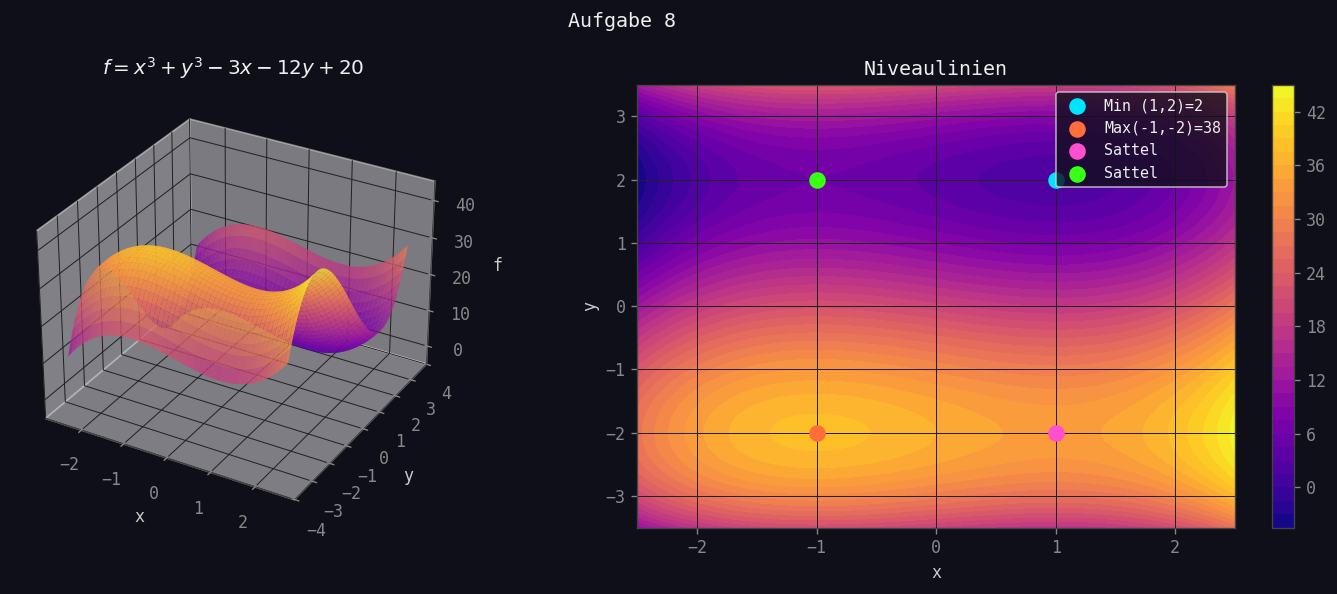

In [18]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f8 = x**3 + y**3 - 3*x - 12*y + 20

f8x = diff(f8, x); f8y = diff(f8, y)
print('f_x =', f8x)
print('f_y =', f8y)

crits8 = solve([f8x, f8y], [x, y])
print('Kritische Punkte:', crits8)

H8 = Matrix([[diff(f8, a, b) for b in [x,y]] for a in [x,y]])
print('Hesse-Matrix H =')
pprint(H8)

for pt in crits8:
    hval  = H8.subs([(x, pt[0]), (y, pt[1])])
    det_h = hval.det()
    fxx   = hval[0,0]
    fval  = f8.subs([(x, pt[0]), (y, pt[1])])
    kind  = ('Minimum'    if det_h > 0 and fxx > 0 else
             'Maximum'    if det_h > 0 and fxx < 0 else
             'Sattelpunkt'if det_h < 0 else 'unbestimmt')
    print(f'  {pt}: det(H)={det_h}, f_xx={fxx} → {kind}, f={fval}')

# ── Plot ──────────────────────────────────────────────────────────────────────
xv = np.linspace(-2.5, 2.5, 300)
yv = np.linspace(-3.5, 3.5, 300)
X8, Y8 = np.meshgrid(xv, yv)
Z8 = X8**3 + Y8**3 - 3*X8 - 12*Y8 + 20

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0f0f1a')
ax1.plot_surface(X8, Y8, np.clip(Z8,-20,60), cmap='plasma', alpha=0.8, linewidth=0)
ax1.set(xlabel='x', ylabel='y', zlabel='f', title=r'$f=x^3+y^3-3x-12y+20$')

ax2 = fig.add_subplot(122)
ax2.set_facecolor('#0f0f1a')
cp = ax2.contourf(X8, Y8, np.clip(Z8,-20,60), levels=40, cmap='plasma')
fig.colorbar(cp, ax=ax2)

special = {(1,2): (CYAN,'Min (1,2)=2'), (-1,-2): (ORANGE,'Max(-1,-2)=38'),
           (1,-2): (PINK,'Sattel'), (-1,2): (GREEN,'Sattel')}
for (px,py),(col,lbl) in special.items():
    ax2.scatter([px],[py], color=col, s=80, zorder=5, label=lbl)
ax2.set(xlabel='x', ylabel='y', title='Niveaulinien')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.suptitle('Aufgabe 8', fontsize=12)
plt.tight_layout()
plt.show()